# LightGBM

**Данные:** `data/train_data_v2.csv` (6 200 строк, 67 признаков)  
**Модель:** LGBMRegressor  
**Подбор гиперпараметров:** Optuna (100 trials)  
**Метрика:** RMSE

## 1. Импорты и конфигурация

In [5]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

import mlflow
import mlflow.lightgbm
import boto3
import os

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

RANDOM_STATE = 42
DATA_PATH    = Path('../data/train_data_v2.csv')
MODELS_DIR   = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

## 1.1 Настройка MLflow

In [6]:
# Коннект к локальному MLflow-серверу (docker-compose)
MLFLOW_TRACKING_URI = "http://localhost:5050"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Доступ к MinIO (S3-совместимый бакет)
os.environ["AWS_ACCESS_KEY_ID"]        = "admin"
os.environ["AWS_SECRET_ACCESS_KEY"]    = "password"
os.environ["MLFLOW_S3_ENDPOINT_URL"]   = "http://localhost:9000"

EXPERIMENT_NAME = "GeoATM-LightGBM"

mlflow.set_experiment(EXPERIMENT_NAME)

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment   : {exp.name}  (id={exp.experiment_id})")
print(f"Artifact loc : {exp.artifact_location}")

Tracking URI : http://localhost:5050
Experiment   : GeoATM-LightGBM  (id=1)
Artifact loc : s3://mlflow-bucket/mlflow/1


## 2. Загрузка данных и признаки

In [7]:
df = pd.read_csv(DATA_PATH)
print(f'Датасет: {df.shape[0]} строк x {df.shape[1]} колонок')
print(f'Таргет: min={df["target"].min():.4f}  max={df["target"].max():.4f}  mean={df["target"].mean():.4f}')

BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center', 'has_subway_nearby',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m', 'nearest_subway_dist_m',
    'nearest_post_offices_dist_m', 'nearest_offices_dist_m',
    'nearest_shops_food_small_dist_m', 'nearest_fitness_sport_dist_m',
    'nearest_hotels_hostels_dist_m', 'land_use_dist_m', 'city_center_dist_m',
    'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m', 'count_pharmacies_hospitals_300m',
    'count_banks_atms_300m', 'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m', 'count_education_300m',
    'count_post_offices_300m', 'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m', 'count_hypermarkets_300m',
    'count_markets_300m', 'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m', 'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'avg_income_q3_2025_rub', 'population_density_per_km2',
]

CATEGORICAL_FEATURES = ['federal_district', 'city_size_category', 'land_use_type', 'atm_group']

ALL_FEATURES = (
    BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES +
    ECONOMIC_FEATURES + CATEGORICAL_FEATURES
)
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f'Итого признаков : {len(ALL_FEATURES)}')
print(f'  Бинарных      : {len(BINARY_FEATURES)}')
print(f'  Расстояний    : {len(DISTANCE_FEATURES)}')
print(f'  Count (300m)  : {len(COUNT_FEATURES)}')
print(f'  Экономических : {len(ECONOMIC_FEATURES)}')
print(f'  Категориальных: {len(CATEGORICAL_FEATURES)}')

Датасет: 6200 строк x 134 колонок
Таргет: min=-0.1450  max=0.2186  mean=0.0008
Итого признаков : 67
  Бинарных      : 17
  Расстояний    : 17
  Count (300m)  : 25
  Экономических : 4
  Категориальных: 4


## 3. Подготовка данных

**Разбивка train / val / test = 70% / 15% / 15%**  
- Optuna и early stopping оптимизируют по **val** - модель не видит test до финального отчёта  
- Финальные метрики считаются один раз на **test**

In [8]:
X = df[ALL_FEATURES].copy()
y = df['target'].values

for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

for col in DISTANCE_FEATURES:
    if col in X.columns:
        X[col] = np.log1p(X[col].clip(lower=0))

strat_col = df['city_size_category'].fillna('unknown')

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=strat_col,
)
strat_trainval = strat_col.loc[X_trainval.index]
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=strat_trainval,
)

# Fit imputer on train only to prevent data leak
num_cols = [c for c in BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES if c in X_train.columns]
imp = SimpleImputer(strategy='median')
X_train.loc[:, num_cols]    = imp.fit_transform(X_train[num_cols])
X_val.loc[:, num_cols]      = imp.transform(X_val[num_cols])
X_test.loc[:, num_cols]     = imp.transform(X_test[num_cols])
X_trainval.loc[:, num_cols] = imp.transform(X_trainval[num_cols])

cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_train.columns]
for split in [X_train, X_val, X_test, X_trainval]:
    for col in cat_cols:
        split[col] = split[col].fillna('unknown').astype('category')

print(f'Train : {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Val   : {X_val.shape}  ({len(X_val)/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')

Train : (4339, 67)  (70%)
Val   : (931, 67)  (15%)
Test  : (930, 67)  (15%)


In [9]:
def report_metrics(model_name, model, X_tr, y_tr, X_te, y_te, fit_time):
    t0 = time.perf_counter()
    y_pred_train = model.predict(X_tr)
    train_pred_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    y_pred_test = model.predict(X_te)
    test_pred_time = time.perf_counter() - t0
    def _m(yt, yp):
        return {'RMSE': round(float(np.sqrt(mean_squared_error(yt, yp))), 4),
                'MAE':  round(float(mean_absolute_error(yt, yp)), 4),
                'R2':   round(float(r2_score(yt, yp)), 4)}
    train_m = _m(y_tr, y_pred_train)
    test_m  = _m(y_te, y_pred_test)
    table = pd.DataFrame([
        {'Split': 'Train', **train_m, 'Fit time, s': round(fit_time, 2), 'Predict time, s': round(train_pred_time, 4)},
        {'Split': 'Test',  **test_m,  'Fit time, s': float('nan'),        'Predict time, s': round(test_pred_time, 4)},
    ]).set_index('Split')
    print(f'\n{model_name}')
    display(table.style.format(
        {'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}',
         'Fit time, s': '{:.2f}', 'Predict time, s': '{:.4f}'},
        na_rep='-'
    ))
    return {
        'Model': model_name,
        'Test RMSE': test_m['RMSE'], 'Test MAE': test_m['MAE'], 'Test R2': test_m['R2'],
        'Fit time, s': round(fit_time, 2), 'Predict time, s': round(test_pred_time, 4),
    }

## 4. Baseline LightGBM

[200]	valid_0's l2: 0.0020141

Baseline LightGBM


,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0292,0.0226,0.8855,1.38,0.0075
Test,0.0452,0.0360,0.7259,-,0.0032


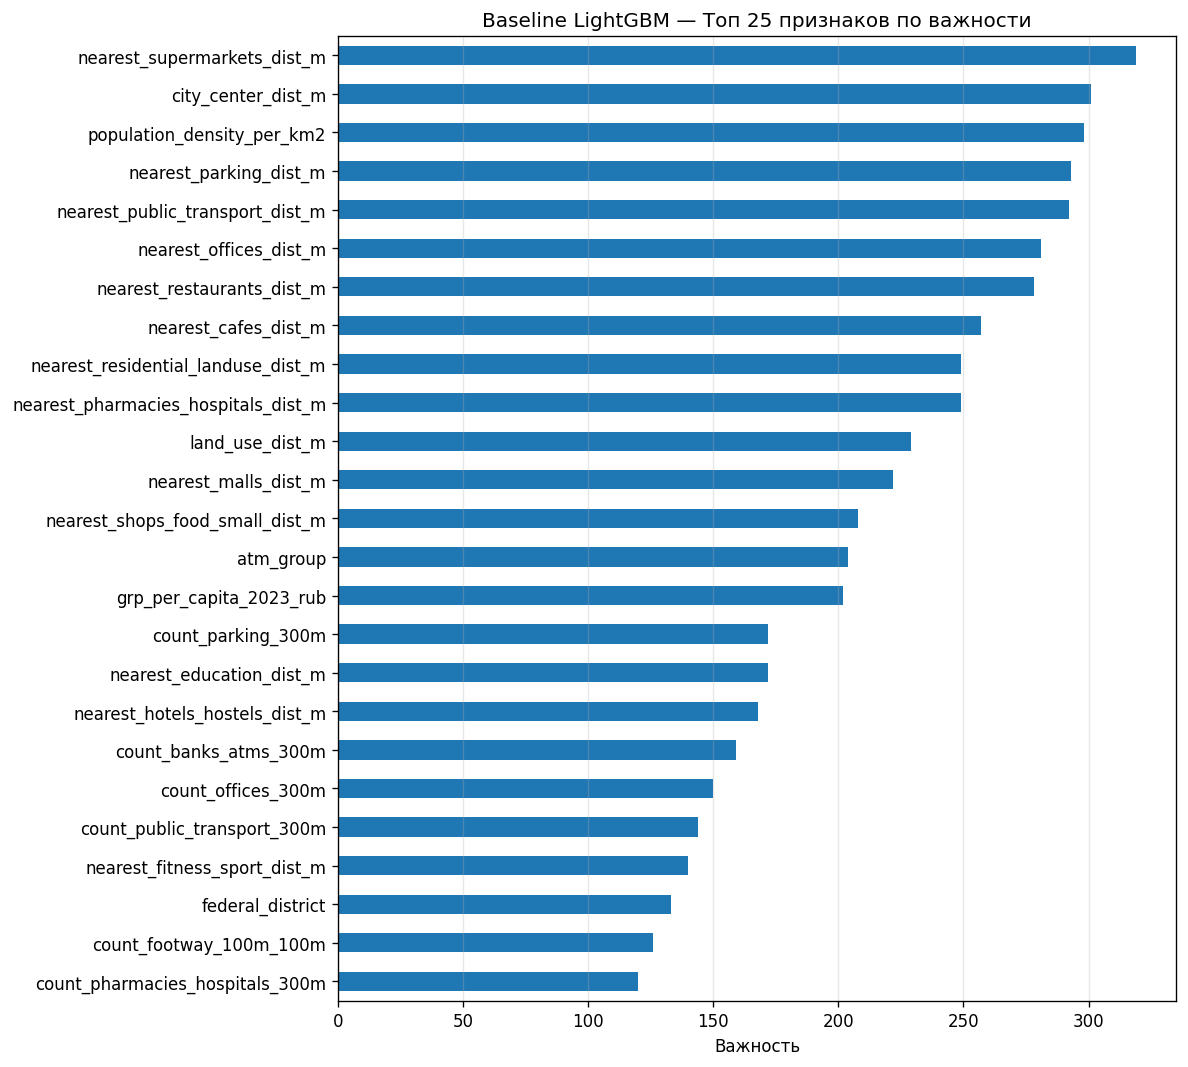

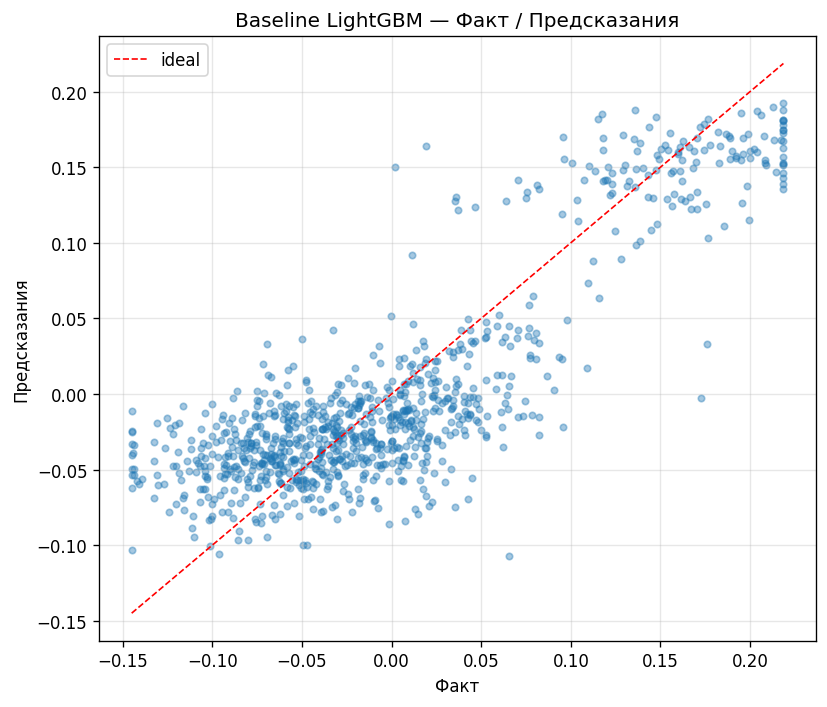

baseline run_id=3d90818d08484e5baa6b5824396b654e
🏃 View run baseline at: http://localhost:5050/#/experiments/1/runs/3d90818d08484e5baa6b5824396b654e
🧪 View experiment at: http://localhost:5050/#/experiments/1
Лучшая итерация: 259


In [10]:
with mlflow.start_run(run_name="baseline") as run_baseline:
    mlflow.set_tag("model_type", "LightGBM")
    mlflow.set_tag("stage", "baseline")

    t0 = time.perf_counter()
    model_base = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )
    model_base.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)],
    )
    fit_time_base = time.perf_counter() - t0

    base_m = report_metrics('Baseline LightGBM', model_base, X_train, y_train, X_test, y_test, fit_time_base)

    # фиксируем гиперпараметры и параметры для воспроизведения эксперимента
    mlflow.log_params({
        "n_estimators":       2000,
        "learning_rate":      0.05,
        "max_depth":          6,
        "num_leaves":         63,
        "random_state":       RANDOM_STATE,
        "early_stopping":     50,
        "best_iteration":     model_base.best_iteration_,
        "data_source":        "train_data_v2.csv",
        "train_size":         len(X_train),
        "val_size":           len(X_val),
        "test_size":          len(X_test),
        "n_features":         len(ALL_FEATURES),
        "imputer_strategy":   "median",
        "distance_transform": "log1p",
    })

    # считаем предсказания
    y_pred_train = model_base.predict(X_train)
    y_pred_val   = model_base.predict(X_val)
    y_pred_test  = model_base.predict(X_test)

    # логгируем метрики на train / val / test
    mlflow.log_metrics({
        "train_RMSE": float(np.sqrt(mean_squared_error(y_train, y_pred_train))),
        "val_RMSE":   float(np.sqrt(mean_squared_error(y_val,   y_pred_val))),
        "test_RMSE":  float(np.sqrt(mean_squared_error(y_test,  y_pred_test))),
        "train_MAE":  float(mean_absolute_error(y_train, y_pred_train)),
        "val_MAE":    float(mean_absolute_error(y_val,   y_pred_val)),
        "test_MAE":   float(mean_absolute_error(y_test,  y_pred_test)),
        "train_R2":   float(r2_score(y_train, y_pred_train)),
        "val_R2":     float(r2_score(y_val,   y_pred_val)),
        "test_R2":    float(r2_score(y_test,  y_pred_test)),
        "fit_time_s": fit_time_base,
    })

    # график важности признаков
    feat_imp = pd.Series(
        model_base.feature_importances_, index=X_train.columns
    ).sort_values(ascending=False)

    fig_fi, ax = plt.subplots(figsize=(10, 9))
    top25 = feat_imp.head(25).iloc[::-1]
    top25.plot.barh(ax=ax)
    ax.set_title('Baseline LightGBM — Топ 25 признаков по важности', fontsize=12)
    ax.set_xlabel('Важность')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    mlflow.log_figure(fig_fi, "feature_importance.png")
    plt.show(); plt.close(fig_fi)

    # график отклонения предсказаний от актуальных значений
    fig_avp, ax = plt.subplots(figsize=(7, 6))
    mn = min(y_test.min(), y_pred_test.min())
    mx = max(y_test.max(), y_pred_test.max())
    ax.scatter(y_test, y_pred_test, alpha=0.4, s=15)
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1, label='ideal')
    ax.set_xlabel('Факт')
    ax.set_ylabel('Предсказания')
    ax.set_title('Baseline LightGBM — Факт / Предсказания')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    mlflow.log_figure(fig_avp, "actual_vs_predicted.png")
    plt.show(); plt.close(fig_avp)

    # сохраняем 10 примеров предсказаний
    sample_df = X_test.head(10).copy()
    sample_df['y_true']    = y_test[:10]
    sample_df['y_pred']    = y_pred_test[:10]
    sample_df['abs_error'] = (sample_df['y_true'] - sample_df['y_pred']).abs()
    mlflow.log_table(sample_df.reset_index(drop=True), artifact_file="sample_predictions.json")

    # сохраняем модель в mlflow
    mlflow.lightgbm.log_model(model_base.booster_, name="model")

    BASE_RUN_ID = run_baseline.info.run_id
    print(f'baseline run_id={BASE_RUN_ID}')

# нужны для итоговой таблицы сравнения
rmse_base = base_m['Test RMSE']
mae_base  = base_m['Test MAE']
r2_base   = base_m['Test R2']
print(f'Лучшая итерация: {model_base.best_iteration_}')

## 5. Подбор гиперпараметров (Optuna, 100 trials)

In [11]:
def objective(trial):
    params = {
        'n_estimators':      1000,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':      RANDOM_STATE,
        'verbosity':         -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )
    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

study = optuna.create_study(
    direction='minimize',
    study_name='lightgbm',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
print('Запускаем Optuna (100 trials)...')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest RMSE (val): {study.best_value:.4f}')
print('Best params:', study.best_params)

# Логируем результаты поиска гиперпараметров
with mlflow.start_run(run_name="optuna_study") as run_study:
    mlflow.set_tag("model_type", "LightGBM")
    mlflow.set_tag("stage", "hyperparameter_search")
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_val_rmse", study.best_value)
    mlflow.log_metric("n_trials", len(study.trials))
    STUDY_RUN_ID = run_study.info.run_id
    print(f'optuna_study run_id={STUDY_RUN_ID}')

Запускаем Optuna (100 trials)...


Best trial: 74. Best value: 0.0437001: 100%|██████████| 100/100 [00:26<00:00,  3.82it/s]



Best RMSE (val): 0.0437
Best params: {'learning_rate': 0.035872281724190797, 'num_leaves': 200, 'max_depth': 10, 'min_child_samples': 49, 'subsample': 0.9859416426623632, 'colsample_bytree': 0.9701831424339988, 'reg_alpha': 7.252647961140868e-05, 'reg_lambda': 4.429714475386216e-08}
optuna_study run_id=1bafa35cdcd24d93be5af898a38e6359
🏃 View run optuna_study at: http://localhost:5050/#/experiments/1/runs/1bafa35cdcd24d93be5af898a38e6359
🧪 View experiment at: http://localhost:5050/#/experiments/1


## 6. Финальная модель (PRD)

[200]	valid_0's l2: 0.00192538
[400]	valid_0's l2: 0.00191062

Final LightGBM (Optuna)


,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Split,,,,,
Train,0.0232,0.0180,0.9276,0.32,0.0169
Test,0.0448,0.0353,0.7307,-,0.0052


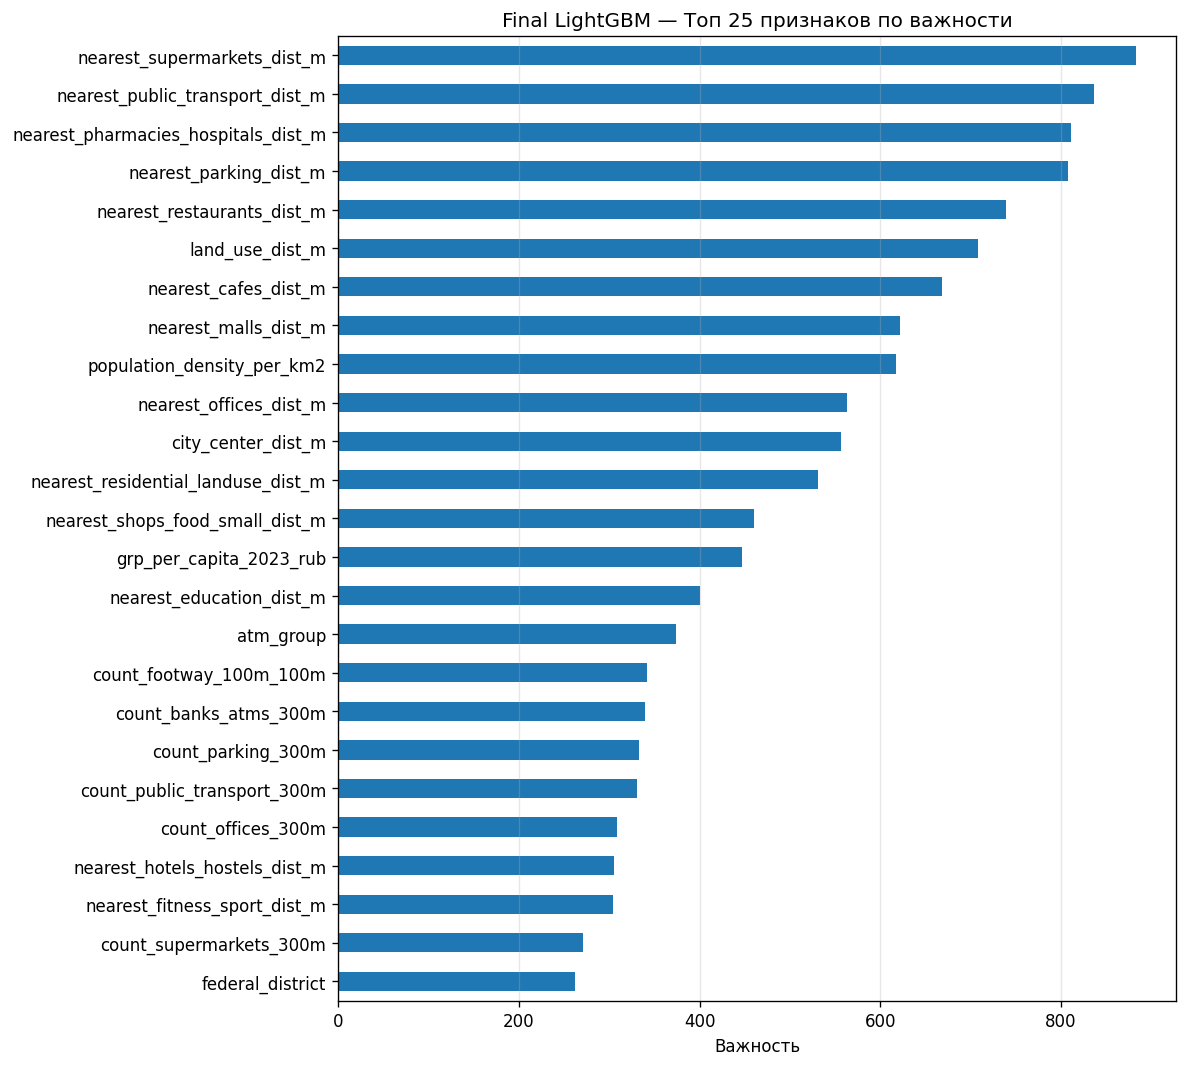

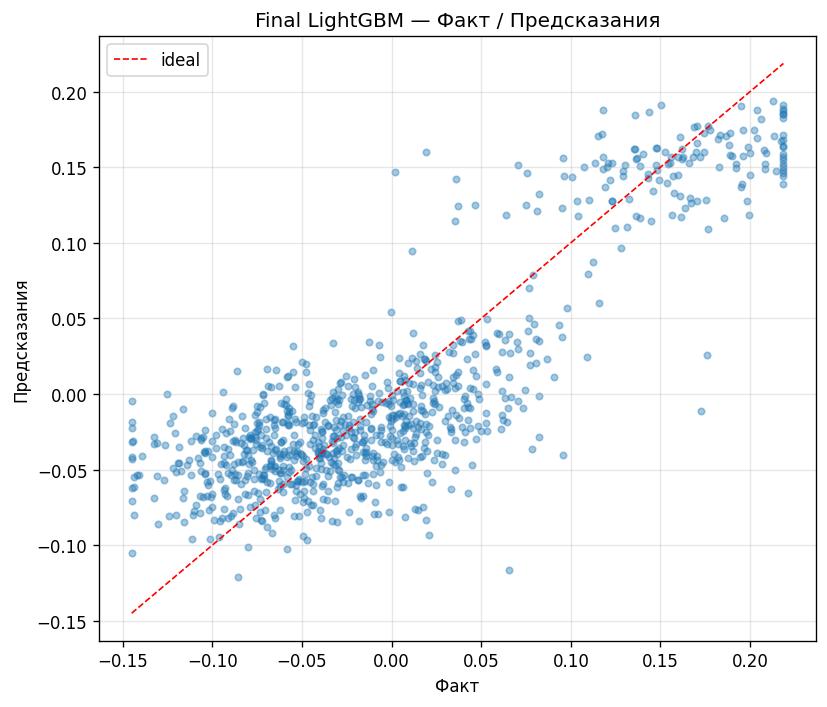

Successfully registered model 'GeoATM-LightGBM-PRD'.
2026/06/02 17:11:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: GeoATM-LightGBM-PRD, version 1
Created version '1' of model 'GeoATM-LightGBM-PRD'.


optuna_final run_id=014c6c70a4204ab98ec10163fa324cf5
model saved -> ..\models\lightgbm_best.txt
🏃 View run optuna_final at: http://localhost:5050/#/experiments/1/runs/014c6c70a4204ab98ec10163fa324cf5
🧪 View experiment at: http://localhost:5050/#/experiments/1
Лучшая итерация: 428


In [12]:
bp = study.best_params

with mlflow.start_run(run_name="optuna_final") as run_final:
    mlflow.set_tag("model_type", "LightGBM")
    mlflow.set_tag("stage", "PRD")
    mlflow.set_tag("tuning", "Optuna-100")

    t0 = time.perf_counter()
    model_final = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=bp['learning_rate'],
        num_leaves=bp['num_leaves'],
        max_depth=bp['max_depth'],
        min_child_samples=bp['min_child_samples'],
        subsample=bp['subsample'],
        colsample_bytree=bp['colsample_bytree'],
        reg_alpha=bp['reg_alpha'],
        reg_lambda=bp['reg_lambda'],
        random_state=RANDOM_STATE,
        verbosity=-1,
    )
    model_final.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)],
    )
    fit_time_final = time.perf_counter() - t0

    final_m = report_metrics('Final LightGBM (Optuna)', model_final, X_train, y_train, X_test, y_test, fit_time_final)

    # фиксируем гиперпараметры и параметры для воспроизведения эксперимента
    mlflow.log_params({
        "n_estimators":          2000,
        "learning_rate":         bp['learning_rate'],
        "num_leaves":            bp['num_leaves'],
        "max_depth":             bp['max_depth'],
        "min_child_samples":     bp['min_child_samples'],
        "subsample":             bp['subsample'],
        "colsample_bytree":      bp['colsample_bytree'],
        "reg_alpha":             bp['reg_alpha'],
        "reg_lambda":            bp['reg_lambda'],
        "random_state":          RANDOM_STATE,
        "early_stopping":        50,
        "best_iteration":        model_final.best_iteration_,
        "optuna_n_trials":       100,
        "optuna_best_val_rmse":  round(study.best_value, 4),
        "data_source":           "train_data_v2.csv",
        "train_size":            len(X_train),
        "val_size":              len(X_val),
        "test_size":             len(X_test),
        "n_features":            len(ALL_FEATURES),
        "imputer_strategy":      "median",
        "distance_transform":    "log1p",
    })

    # считаем предсказания
    y_pred_train = model_final.predict(X_train)
    y_pred_val   = model_final.predict(X_val)
    y_pred_test  = model_final.predict(X_test)

    # логгируем метрики на train / val / test
    mlflow.log_metrics({
        "train_RMSE": float(np.sqrt(mean_squared_error(y_train, y_pred_train))),
        "val_RMSE":   float(np.sqrt(mean_squared_error(y_val,   y_pred_val))),
        "test_RMSE":  float(np.sqrt(mean_squared_error(y_test,  y_pred_test))),
        "train_MAE":  float(mean_absolute_error(y_train, y_pred_train)),
        "val_MAE":    float(mean_absolute_error(y_val,   y_pred_val)),
        "test_MAE":   float(mean_absolute_error(y_test,  y_pred_test)),
        "train_R2":   float(r2_score(y_train, y_pred_train)),
        "val_R2":     float(r2_score(y_val,   y_pred_val)),
        "test_R2":    float(r2_score(y_test,  y_pred_test)),
        "fit_time_s": fit_time_final,
    })

    # график важности признаков
    feat_imp = pd.Series(
        model_final.feature_importances_, index=X_train.columns
    ).sort_values(ascending=False)

    fig_fi, ax = plt.subplots(figsize=(10, 9))
    top25 = feat_imp.head(25).iloc[::-1]
    top25.plot.barh(ax=ax)
    ax.set_title('Final LightGBM — Топ 25 признаков по важности', fontsize=12)
    ax.set_xlabel('Важность')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    mlflow.log_figure(fig_fi, "feature_importance.png")
    plt.show(); plt.close(fig_fi)

    # график отклонения предсказаний от актуальных значений
    fig_avp, ax = plt.subplots(figsize=(7, 6))
    mn = min(y_test.min(), y_pred_test.min())
    mx = max(y_test.max(), y_pred_test.max())
    ax.scatter(y_test, y_pred_test, alpha=0.4, s=15)
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1, label='ideal')
    ax.set_xlabel('Факт')
    ax.set_ylabel('Предсказания')
    ax.set_title('Final LightGBM — Факт / Предсказания')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    mlflow.log_figure(fig_avp, "actual_vs_predicted.png")
    plt.show(); plt.close(fig_avp)

    # сохраняем 10 примеров предсказаний
    sample_df = X_test.head(10).copy()
    sample_df['y_true']    = y_test[:10]
    sample_df['y_pred']    = y_pred_test[:10]
    sample_df['abs_error'] = (sample_df['y_true'] - sample_df['y_pred']).abs()
    mlflow.log_table(sample_df.reset_index(drop=True), artifact_file="sample_predictions.json")

    # сохраняем финальную модель (train+val) и регистрируем как PRD
    model_save = lgb.LGBMRegressor(
        n_estimators=model_final.best_iteration_,
        learning_rate=bp['learning_rate'],
        num_leaves=bp['num_leaves'],
        max_depth=bp['max_depth'],
        min_child_samples=bp['min_child_samples'],
        subsample=bp['subsample'],
        colsample_bytree=bp['colsample_bytree'],
        reg_alpha=bp['reg_alpha'],
        reg_lambda=bp['reg_lambda'],
        random_state=RANDOM_STATE,
        verbosity=-1,
    )
    model_save.fit(X_trainval, y_trainval)
    save_path = str(MODELS_DIR / 'lightgbm_best.txt')
    model_save.booster_.save_model(save_path)
    mlflow.log_artifact(save_path, artifact_path="model_txt")
    mlflow.lightgbm.log_model(
        model_save.booster_,
        name="model",
        registered_model_name="GeoATM-LightGBM-PRD",
    )

    FINAL_RUN_ID = run_final.info.run_id
    print(f'optuna_final run_id={FINAL_RUN_ID}')
    print(f'model saved -> {save_path}')

# нужны для итоговой таблицы сравнения
rmse_final = final_m['Test RMSE']
mae_final  = final_m['Test MAE']
r2_final   = final_m['Test R2']
print(f'Лучшая итерация: {model_final.best_iteration_}')

## 7. Итоги

In [13]:
summary = pd.DataFrame([
    {'Эксперимент': 'Baseline', 'RMSE': rmse_base,  'MAE': mae_base,  'R2': r2_base,
     'Fit time, s': base_m['Fit time, s'],  'Predict time, s': base_m['Predict time, s']},
    {'Эксперимент': 'Optuna (PRD)', 'RMSE': rmse_final, 'MAE': mae_final, 'R2': r2_final,
     'Fit time, s': final_m['Fit time, s'], 'Predict time, s': final_m['Predict time, s']},
]).set_index('Эксперимент')

display(
    summary.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}',
             'Fit time, s': '{:.2f}', 'Predict time, s': '{:.4f}'})
    .apply(lambda s: ['font-weight: bold' if v == s.min() else '' for v in s], subset=['RMSE', 'MAE'])
    .apply(lambda s: ['font-weight: bold' if v == s.max() else '' for v in s], subset=['R2'])
)

,RMSE,MAE,R2,"Fit time, s","Predict time, s"
Эксперимент,,,,,
Baseline,0.0452,0.0360,0.7259,1.38,0.0032
Optuna (PRD),0.0448,0.0353,0.7307,0.32,0.0052
